In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
customer_df = pd.read_csv("D:/Techmaghi/projects/5 (final)/dataset/final/customer_churn_dataset_clean(customer final).csv")

print("Customer Shape:", customer_df.shape)
print(customer_df.info())
print(customer_df.head())

Customer Shape: (15431, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15431 entries, 0 to 15430
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   15431 non-null  int64  
 1   Churn                        15431 non-null  int64  
 2   Tenure                       14713 non-null  float64
 3   PreferredLoginDevice         15431 non-null  int64  
 4   CityTier                     15431 non-null  int64  
 5   WarehouseToHome              14768 non-null  float64
 6   PreferredPaymentMode         15431 non-null  int64  
 7   Gender                       15431 non-null  int64  
 8   HourSpendOnApp               14727 non-null  float64
 9   NumberOfDeviceRegistered     15431 non-null  int64  
 10  PreferedOrderCat             15431 non-null  int64  
 11  SatisfactionScore            15431 non-null  int64  
 12  MaritalStatus                15431 non-null  i

In [3]:
customer_df.describe(include='all')

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,...,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,OrderFrequency,CustomerValue,InactivityScore,ComplaintRate,EngagementScore
count,15431.000000,15431.000000,14713.000000,15431.000000,15431.000000,14768.000000,15431.000000,15431.000000,14727.000000,15431.000000,...,14741.000000,14750.000000,14695.000000,14585.000000,15431.000000,13977.000000,14695.000000,13867.000000,14695.000000,13991.000000
mean,52830.799365,0.164345,10.187929,0.926317,1.643510,15.626828,3.539174,0.605016,2.933863,3.685827,...,15.681501,1.753288,2.978088,4.557833,177.038975,0.602905,566.298461,0.906646,0.095428,9.165321
std,1623.975937,0.370600,8.469628,0.714321,0.912786,8.648100,1.386727,0.488863,0.720831,1.019667,...,3.678568,1.893769,2.896412,3.680551,48.551359,0.942344,699.518161,1.586626,0.169147,9.375338
min,50002.000000,0.000000,0.000000,0.000000,1.000000,5.000000,0.000000,0.000000,0.000000,1.000000,...,11.000000,0.000000,1.000000,0.000000,0.000000,0.016393,0.000000,0.000000,0.000000,0.000000
25%,51417.000000,0.000000,2.000000,0.000000,1.000000,9.000000,3.000000,0.000000,2.000000,3.000000,...,13.000000,1.000000,1.000000,2.000000,145.745000,0.125000,165.530000,0.181818,0.000000,3.000000
50%,52832.000000,0.000000,9.000000,1.000000,1.000000,13.000000,4.000000,1.000000,3.000000,4.000000,...,15.000000,1.000000,2.000000,3.000000,163.220000,0.285714,322.340000,0.470588,0.000000,6.000000
75%,54234.500000,0.000000,16.000000,1.000000,3.000000,21.000000,4.000000,1.000000,3.000000,4.000000,...,18.000000,2.000000,3.000000,7.000000,197.020000,1.000000,571.280000,1.000000,0.125000,9.000000
max,55630.000000,1.000000,61.000000,2.000000,3.000000,127.000000,6.000000,1.000000,5.000000,6.000000,...,26.000000,16.000000,16.000000,46.000000,324.990000,15.000000,5127.200000,46.000000,0.500000,64.000000


In [4]:

customer_df.drop(columns=["CustomerID"], inplace=True)

num_cols = customer_df.select_dtypes(include=np.number).columns
customer_df[num_cols] = customer_df[num_cols].fillna(customer_df[num_cols].median())

cat_cols = customer_df.select_dtypes(include="object").columns
for col in cat_cols:
    customer_df[col] = customer_df[col].fillna(customer_df[col].mode()[0])


customer_df["PreferredLoginDevice"] = (
    customer_df["PreferredLoginDevice"]
    .astype(str)
    .str.strip()
    .replace({
        "Phone": "Mobile Phone",
        "mobile phone": "Mobile Phone",
        "Mobile phone": "Mobile Phone"
    })
)

customer_df["PreferredPaymentMode"] = (
    customer_df["PreferredPaymentMode"]
    .astype(str)
    .str.strip()
    .replace({
        "CC":"Credit Card",
        "COD":"Cash on Delivery",
        "E wallet":"E Wallet"
    })
)

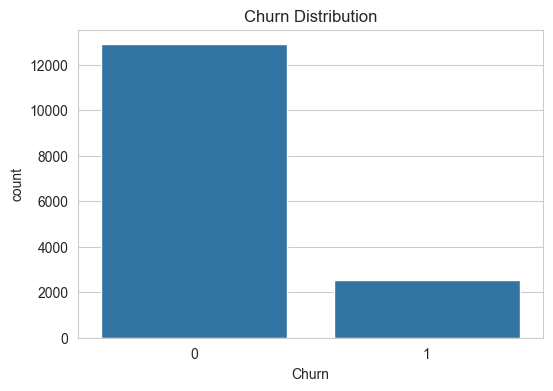

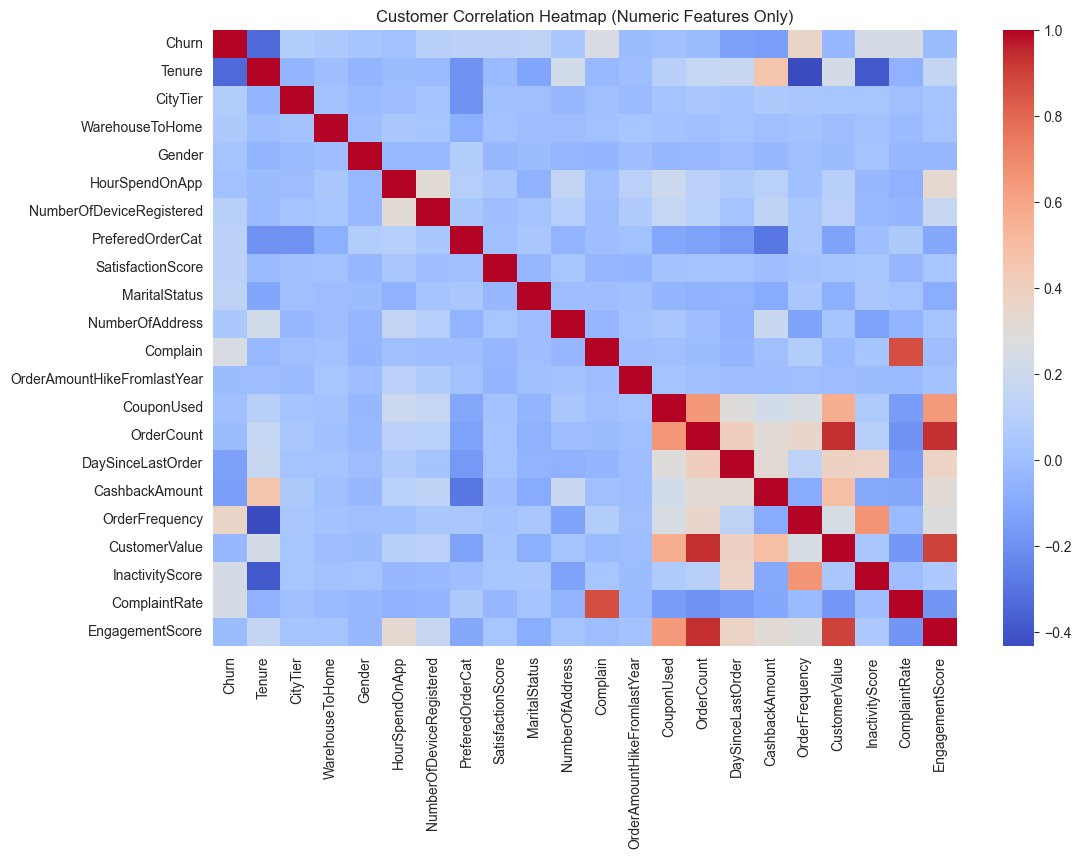

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=customer_df)
plt.title("Churn Distribution")
plt.show()


plt.figure(figsize=(12,8))
numeric_df = customer_df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm")
plt.title("Customer Correlation Heatmap (Numeric Features Only)")
plt.show()

In [6]:
transaction_df = pd.read_csv("D:/Techmaghi/projects/5 (final)/dataset/final/Amazon Sale Report(transaction).csv")

print("Transaction Shape:", transaction_df.shape)
print(transaction_df.info())
print(transaction_df.head())


C:\Users\kichu\AppData\Local\Temp\ipykernel_23748\3535675753.py:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  transaction_df = pd.read_csv("D:/Techmaghi/projects/5 (final)/dataset/final/Amazon Sale Report(transaction).csv")


Transaction Shape: (128975, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Am

In [7]:
transaction_df.describe(include='all')

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
count,128975.000000,128975,128975,128975,128975,128975,128975,128975,128975,128975,...,121180,121180.000000,128942,128942,128942.000000,128942,79822,128975,39277,79925
unique,NaN,120378,91,13,2,2,2,1377,7195,9,...,1,NaN,8955,69,NaN,1,5787,2,1,1
top,NaN,171-5057375-2831560,05-03-22,Shipped,Amazon,Amazon.in,Expedited,JNE3797,JNE3797-KR-L,Set,...,INR,NaN,BENGALURU,MAHARASHTRA,NaN,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Easy Ship,False
freq,NaN,12,2085,77804,89698,128851,88615,4224,773,50284,...,121180,NaN,11217,22260,NaN,128942,46100,128104,39277,79925
mean,64487.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,648.561465,NaN,NaN,463966.236509,NaN,NaN,NaN,NaN,NaN
std,37232.019822,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,281.211687,NaN,NaN,191476.764941,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,NaN,NaN,110001.000000,NaN,NaN,NaN,NaN,NaN
25%,32243.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,449.000000,NaN,NaN,382421.000000,NaN,NaN,NaN,NaN,NaN
50%,64487.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,605.000000,NaN,NaN,500033.000000,NaN,NaN,NaN,NaN,NaN
75%,96730.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,788.000000,NaN,NaN,600024.000000,NaN,NaN,NaN,NaN,NaN


In [8]:
columns_to_drop = [
    "index",
    "Order ID",
    "SKU",
    "ASIN",
    "promotion-ids",
    "Unnamed: 22",
    "ship-postal-code",
    "currency"
]

transaction_df.drop(columns=columns_to_drop, inplace=True, errors='ignore')


transaction_df["Date"] = pd.to_datetime(transaction_df["Date"], errors="coerce")


transaction_df = transaction_df[transaction_df["Status"] != "Cancelled"]


transaction_df.fillna(method="ffill", inplace=True)

# transaction_df["Date"] = pd.to_datetime(transaction_df["Date"])

C:\Users\kichu\AppData\Local\Temp\ipykernel_23748\1631019883.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  transaction_df["Date"] = pd.to_datetime(transaction_df["Date"], errors="coerce")
C:\Users\kichu\AppData\Local\Temp\ipykernel_23748\1631019883.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  transaction_df.fillna(method="ffill", inplace=True)


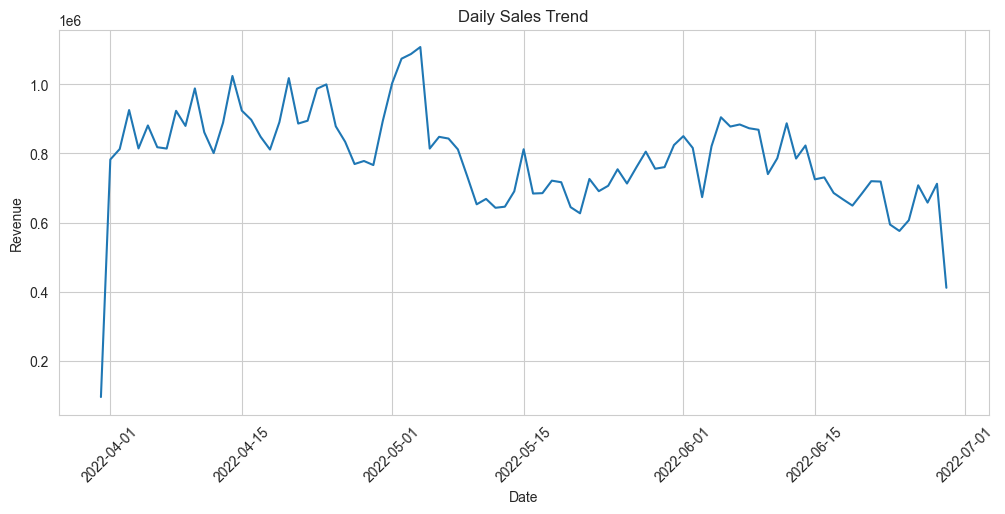

In [9]:
daily_sales = transaction_df.groupby("Date")["Amount"].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(daily_sales["Date"], daily_sales["Amount"])
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [10]:
product_df = pd.read_csv("D:/Techmaghi/projects/5 (final)/dataset/final/articles(product).csv")

print("Product Shape:", product_df.shape)
print(product_df.info())
print(product_df.head())

Product Shape: (105542, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   article_id                    105542 non-null  int64 
 1   product_code                  105542 non-null  int64 
 2   prod_name                     105542 non-null  object
 3   product_type_no               105542 non-null  int64 
 4   product_type_name             105542 non-null  object
 5   product_group_name            105542 non-null  object
 6   graphical_appearance_no       105542 non-null  int64 
 7   graphical_appearance_name     105542 non-null  object
 8   colour_group_code             105542 non-null  int64 
 9   colour_group_name             105542 non-null  object
 10  perceived_colour_value_id     105542 non-null  int64 
 11  perceived_colour_value_name   105542 non-null  object
 12  perceived_colour_master_id    

In [11]:
product_df.describe(include='all')

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
count,1.055420e+05,105542.000000,105542,105542.000000,105542,105542,1.055420e+05,105542,105542.000000,105542,...,105542,105542,105542,105542.000000,105542,105542.000000,105542,105542.000000,105542,105126
unique,NaN,NaN,45875,NaN,131,19,NaN,30,NaN,50,...,250,10,10,NaN,5,NaN,56,NaN,21,43404
top,NaN,NaN,Dragonfly dress,NaN,Trousers,Garment Upper body,NaN,Solid,NaN,Black,...,Jersey,A,Ladieswear,NaN,Ladieswear,NaN,Womens Everyday Collection,NaN,Jersey Fancy,T-shirt in printed cotton jersey.
freq,NaN,NaN,98,NaN,11169,42741,NaN,49747,NaN,22670,...,4604,26001,26001,NaN,39737,NaN,7295,NaN,21445,159
mean,6.984246e+08,698424.563378,NaN,234.861875,NaN,NaN,1.009515e+06,NaN,32.233822,NaN,...,NaN,NaN,NaN,3.171534,NaN,42.664219,NaN,1010.438290,NaN,NaN
std,1.284624e+08,128462.384432,NaN,75.049308,NaN,NaN,2.241359e+04,NaN,28.086154,NaN,...,NaN,NaN,NaN,4.353234,NaN,23.260105,NaN,6.731023,NaN,NaN
min,1.087750e+08,108775.000000,NaN,-1.000000,NaN,NaN,-1.000000e+00,NaN,-1.000000,NaN,...,NaN,NaN,NaN,1.000000,NaN,2.000000,NaN,1001.000000,NaN,NaN
25%,6.169925e+08,616992.500000,NaN,252.000000,NaN,NaN,1.010008e+06,NaN,9.000000,NaN,...,NaN,NaN,NaN,1.000000,NaN,20.000000,NaN,1005.000000,NaN,NaN
50%,7.022130e+08,702213.000000,NaN,259.000000,NaN,NaN,1.010016e+06,NaN,14.000000,NaN,...,NaN,NaN,NaN,2.000000,NaN,46.000000,NaN,1009.000000,NaN,NaN
75%,7.967030e+08,796703.000000,NaN,272.000000,NaN,NaN,1.010016e+06,NaN,52.000000,NaN,...,NaN,NaN,NaN,4.000000,NaN,61.000000,NaN,1017.000000,NaN,NaN


In [12]:
product_df.columns = product_df.columns.str.strip().str.lower()

product_df.drop(columns=["article_id", "product_code"], inplace=True, errors="ignore")

print(product_df.isnull().sum())

text_cols = product_df.select_dtypes(include="object").columns
for col in text_cols:
    product_df[col] = product_df[col].fillna("unknown")

print("Product dataset cleaned successfully.")

prod_name                         0
product_type_no                   0
product_type_name                 0
product_group_name                0
graphical_appearance_no           0
graphical_appearance_name         0
colour_group_code                 0
colour_group_name                 0
perceived_colour_value_id         0
perceived_colour_value_name       0
perceived_colour_master_id        0
perceived_colour_master_name      0
department_no                     0
department_name                   0
index_code                        0
index_name                        0
index_group_no                    0
index_group_name                  0
section_no                        0
section_name                      0
garment_group_no                  0
garment_group_name                0
detail_desc                     416
dtype: int64
Product dataset cleaned successfully.


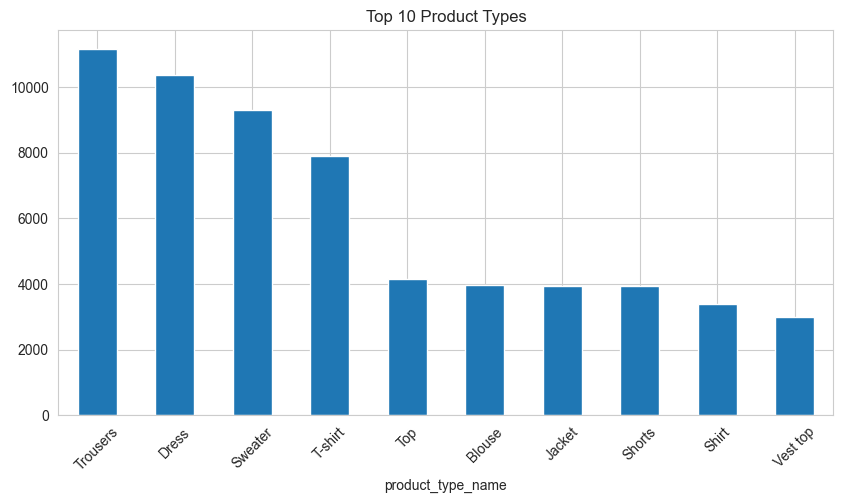

In [13]:
plt.figure(figsize=(10,5))
product_df["product_type_name"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Product Types")
plt.xticks(rotation=45)
plt.show()

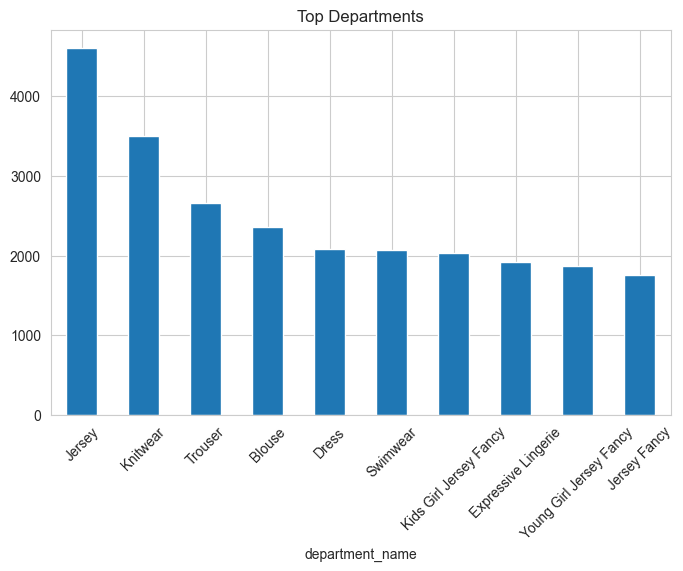

In [14]:
plt.figure(figsize=(8,5))
product_df["department_name"].value_counts().head(10).plot(kind="bar")
plt.title("Top Departments")
plt.xticks(rotation=45)
plt.show()

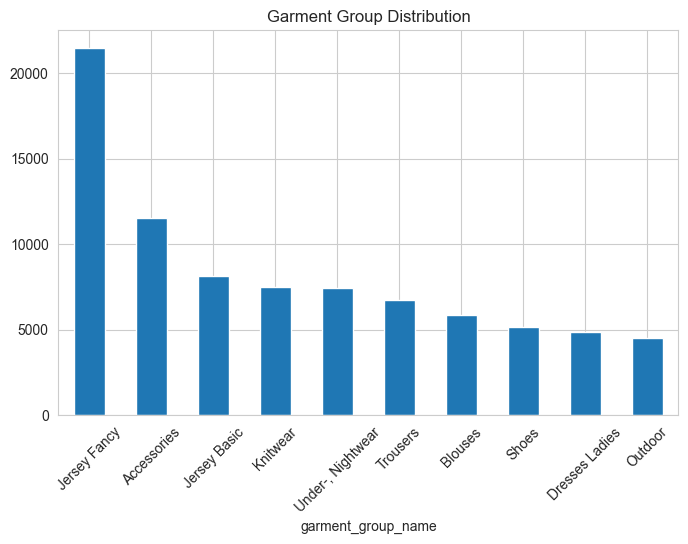

In [15]:
plt.figure(figsize=(8,5))
product_df["garment_group_name"].value_counts().head(10).plot(kind="bar")
plt.title("Garment Group Distribution")
plt.xticks(rotation=45)
plt.show()

In [16]:
customer_df.to_csv("cleaned_customer.csv", index=False)
transaction_df.to_csv("cleaned_transaction.csv", index=False)
product_df.to_csv("cleaned_product.csv", index=False)

print("All datasets cleaned and saved successfully.")

All datasets cleaned and saved successfully.
